# KMeans RFM Customer Segmentation

Exploratory analysis and training notebook for KMeans-based customer segmentation using **RFM** (Recency, Frequency, Monetary) features.

| | |
|---|---|
| **Dataset** | Olist E-commerce (2016–2018) |
| **Training period** | 2016-09-04 → 2017-02-28 |
| **Algorithm** | KMeans with RobustScaler |
| **Segments** | Champions · Potential · At Risk |

In [1]:
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
from os import getenv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import logging
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from supabase import create_client
import yaml

log = logging.getLogger(__name__)

In [2]:
# import kmeans_service
import sys, os
sys.path.insert(0, os.path.abspath('..'))
print(sys.path[0])
from plugins.services.kmeans_service import *

d:\FPTU_Education\olist-capstone-workspace\airflow-server


## 1. Configuration & Database Connection

Load training parameters from `contexts/kmeans_rfm_training.yaml` and connect to PostgreSQL via SQLAlchemy.

In [3]:
# Load configuration from YAML file
config = yaml.safe_load(open(sys.path[0] + r'\contexts\kmeans_rfm_training.yaml'))

training_schema = config['postgres']['training']['schema']
training_table = config['postgres']['training']['table']
start_date = config['postgres']['training']['start_date']
end_date = config['postgres']['training']['end_date']
training_query = config['postgres']['training']['query']

# load environment variables
load_dotenv()
database = getenv("DATABASE")
user = getenv("USER")
password = getenv("PASSWORD")
host = getenv("HOST")
port = getenv("PORT")
supabase_url = getenv("SUPABASE_URL")
supabase_key = getenv("SUPABASE_KEY")

## 2. Data Extraction

Extract RFM features from the database for the training period.

| Feature | Description |
|---|---|
| **Recency** | Days since last purchase relative to `end_date` |
| **Frequency** | Number of distinct orders |
| **Monetary** | Total payment value (BRL) |

In [4]:
engine = create_engine(f'postgresql://{user}:{password}@{host}:{port}/{database}')
df = extract_data(engine, training_query, start_date=start_date, end_date=end_date)

## 3. Exploratory Data Analysis (EDA)

Inspect data distribution across RFM dimensions before clustering.

In [5]:
df.sort_values('frequency', ascending=False).head()

,customer_unique_id,recency,frequency,monetary
221,12f5d6e1cbf93dafd9dcc19095df0b3d,55,6,110.72
1767,a239b8e2fbce33780f1f1912e2ee5275,12,4,518.50
1443,83e7958a94bd7f74a9414d8782f87628,55,4,73.48
1247,728e4a7d0db4845270091ded0923c71f,55,3,46.86
511,2e43e031f10de28e557c35ef668f9396,34,3,350.97


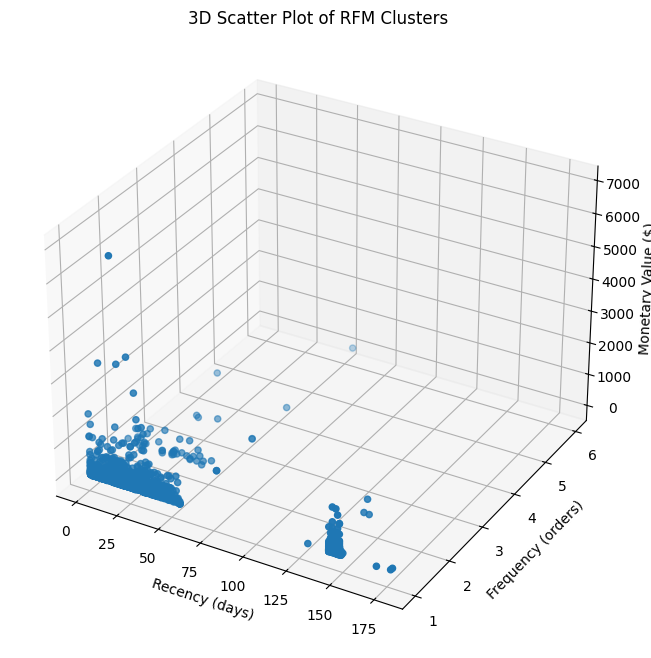

In [10]:
# 3D Scatter Plot of RFM Clusters
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['recency'].astype(float), df['frequency'].astype(float), df['monetary'].astype(float))

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (orders)')
ax.set_zlabel('Monetary Value ($)')
ax.set_title('3D Scatter Plot of RFM Clusters')

plt.show()

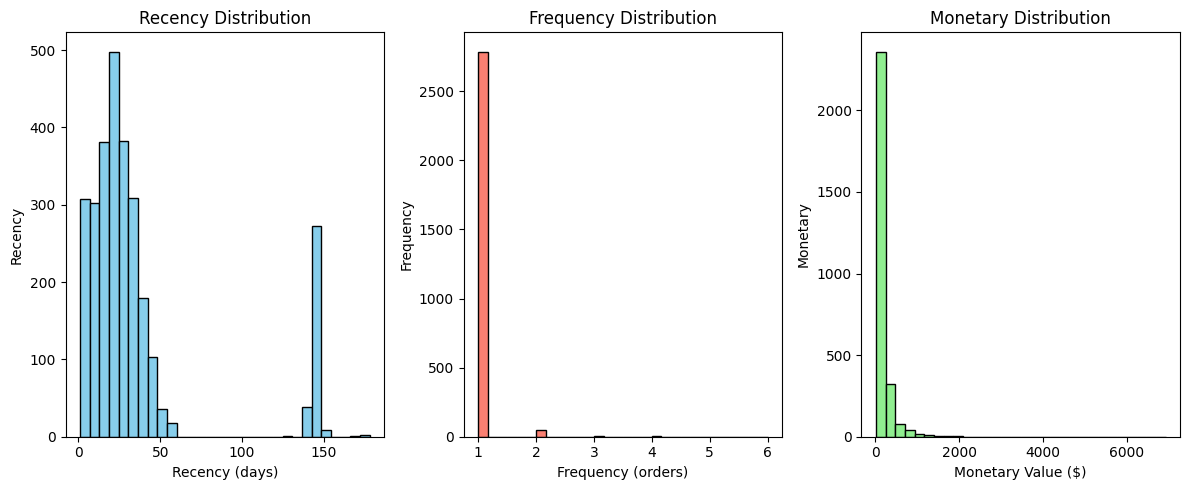

In [11]:
# feature histograms
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.hist(df['recency'], bins=30, color='skyblue', edgecolor='black')
plt.title('Recency Distribution')
plt.xlabel('Recency (days)')
plt.ylabel('Recency')

plt.subplot(1, 3, 2)
plt.hist(df['frequency'], bins=30, color='salmon', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency (orders)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(df['monetary'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Monetary Distribution')
plt.xlabel('Monetary Value ($)')
plt.ylabel('Monetary')

plt.tight_layout()
plt.show()

## 4. Preprocessing

- Apply `log1p` transform to `monetary` to reduce right skew
- Scale all features using `RobustScaler` (median + IQR) — robust to outliers
- Compare original vs scaled distributions to verify transformation

In [61]:
scaled, scaler = preprocess(df)

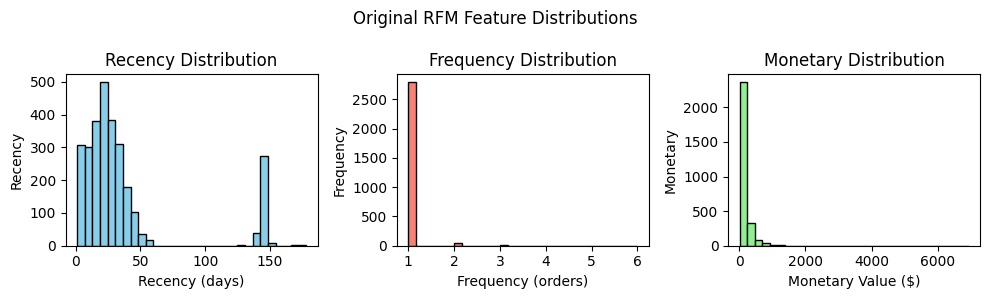

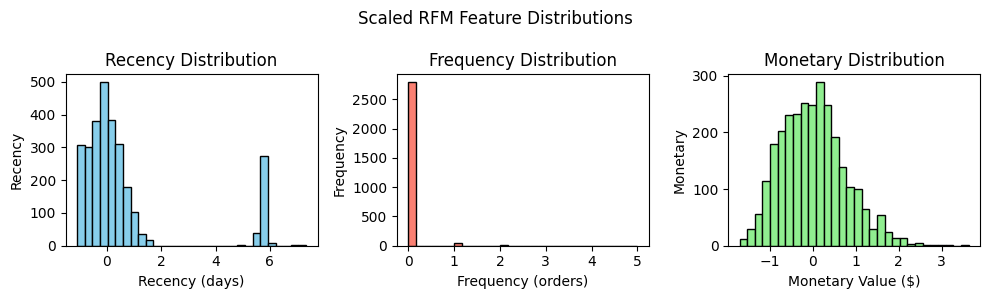

In [62]:
# Original feature histograms
plt.figure(figsize=(10, 3))
plt.suptitle('Original RFM Feature Distributions')

plt.subplot(1, 3, 1)
plt.hist(df['recency'], bins=30, color='skyblue', edgecolor='black')
plt.title('Recency Distribution')
plt.xlabel('Recency (days)')
plt.ylabel('Recency')

plt.subplot(1, 3, 2)
plt.hist(df['frequency'], bins=30, color='salmon', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency (orders)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(df['monetary'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Monetary Distribution')
plt.xlabel('Monetary Value ($)')
plt.ylabel('Monetary')

plt.tight_layout()
plt.show()

# Scaled feature histograms
df_scaled = pd.DataFrame(scaled, columns=['recency', 'frequency', 'monetary'])
plt.figure(figsize=(10, 3))
plt.suptitle('Scaled RFM Feature Distributions')

plt.subplot(1, 3, 1)
plt.hist(df_scaled['recency'], bins=30, color='skyblue', edgecolor='black')
plt.title('Recency Distribution')
plt.xlabel('Recency (days)')
plt.ylabel('Recency')

plt.subplot(1, 3, 2)
plt.hist(df_scaled['frequency'], bins=30, color='salmon', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency (orders)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(df_scaled['monetary'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Monetary Distribution')
plt.xlabel('Monetary Value ($)')
plt.ylabel('Monetary')

plt.tight_layout()
plt.show()

## 5. Finding Optimal k — Elbow Method & Silhouette Score

Evaluate `k` from 2 to 7 on **scaled data** using two metrics:

| Metric | What to look for |
|---|---|
| **Inertia (Elbow)** | Point where inertia starts decreasing slowly — the "elbow" |
| **Silhouette Score** | Higher = better cluster separation (range: -1 to 1) |

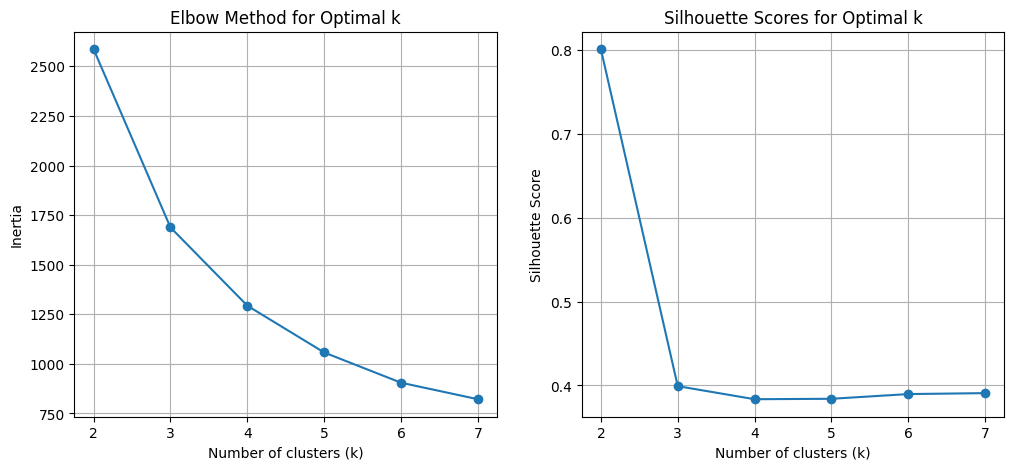

In [63]:
# Elbow Method
from sklearn.cluster import KMeans

inertia = []
silhouette_scores = []
for k in range (2, 8):
    # Fit KMeans
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled)

    # Append inertia
    inertia.append(kmeans.inertia_)

    # Calculate silhouette score
    sil = silhouette_score(scaled, labels)
    silhouette_scores.append(sil)

# Plot inertia
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(2, 8), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(range(2, 8), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid()

plt.show()

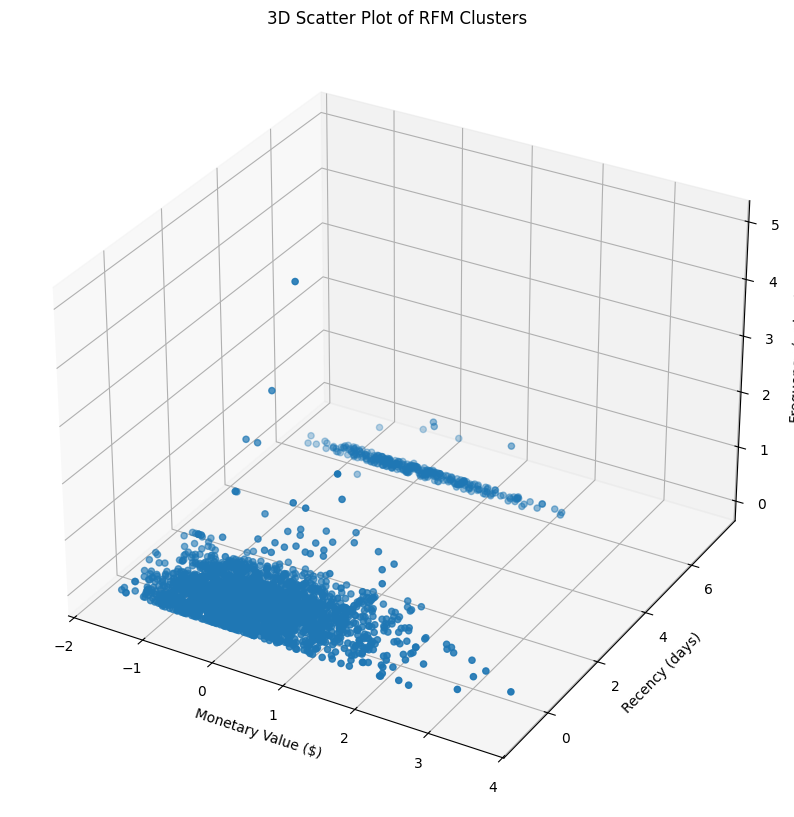

In [64]:
# 3D Scatter Plot of RFM Clusters
df_scaled = pd.DataFrame(scaled, columns=['recency', 'frequency', 'monetary'])

fig = plt.figure(figsize=(10, 18))

ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    df_scaled['monetary'].astype(float),
    df_scaled['recency'].astype(float),
    df_scaled['frequency'].astype(float)
)

ax.set_xlabel('Monetary Value ($)')
ax.set_ylabel('Recency (days)')
ax.set_zlabel('Frequency (orders)')

ax.set_title('3D Scatter Plot of RFM Clusters')

plt.show()

## 6. Model Training

Train KMeans with `n_clusters=3` on scaled RFM data.  
Labels are assigned based on centroid ranking across all 3 dimensions:

| Segment | Recency | Frequency | Monetary |
|---|---|---|---|
| **champions** | low (recent) | highest | highest |
| **potential** | low (recent) | medium | medium |
| **at_risk** | high (inactive) | lowest | lowest |

In [19]:
km = train_KMeans(scaled, n_clusters=3)
label_map = label_clusters(km, scaler)

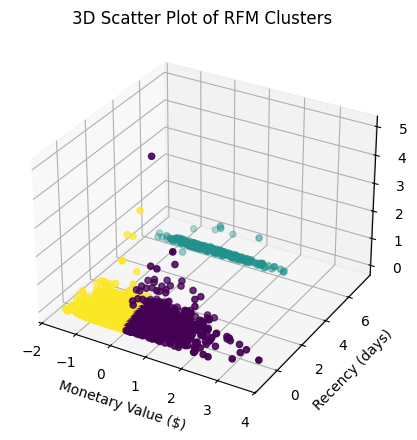

In [68]:
# 3D Scatter Plot of RFM Clusters
km = KMeans(n_clusters=3, random_state=42)
km.fit(scaled)

df_scaled = pd.DataFrame(scaled, columns=['recency', 'frequency', 'monetary'])

fig = plt.figure(figsize=(5, 5))

ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    df_scaled['monetary'].astype(float),
    df_scaled['recency'].astype(float),
    df_scaled['frequency'].astype(float),
    c=km.labels_, cmap='viridis', marker='o'
)

ax.set_xlabel('Monetary Value ($)')
ax.set_ylabel('Recency (days)')
ax.set_zlabel('Frequency (orders)')
ax.set_title('3D Scatter Plot of RFM Clusters')

plt.show()

## 7. Cluster Analysis & Results

Inspect cluster assignments and visualize final segmentation in 3D RFM space.

In [28]:
print(km)
print(km.cluster_centers_)
print(km.inertia_)
print(km.labels_)
print(km.n_iter_)
print(km.n_features_in_)

KMeans(n_clusters=3, random_state=42)
[[-0.0224924   0.04        0.64513069]
 [ 5.79673721  0.00925926  0.10647392]
 [-0.13547655  0.01266766 -0.54676207]]
1687.7718260449349
[2 2 1 ... 0 0 2]
4
3


In [65]:
df_result = df.copy()
km = KMeans(n_clusters=3, random_state=42)
km.fit(scaled)
df_result['cluster'] = km.labels_

df_result.head()

,customer_unique_id,recency,frequency,monetary,cluster
0,00115fc7123b5310cf6d3a3aa932699e,39,1,76.11,2
1,002b4cd83fabaffaa475f78ea5ef3e08,28,1,64.42,2
2,0032c76b20340da25249092a268ce66c,146,1,144.94,1
3,0071f46a072a9ae25bbe4438b15efe9c,28,1,174.54,0
4,0087eede471173af78d789df249c3a45,13,1,151.11,0


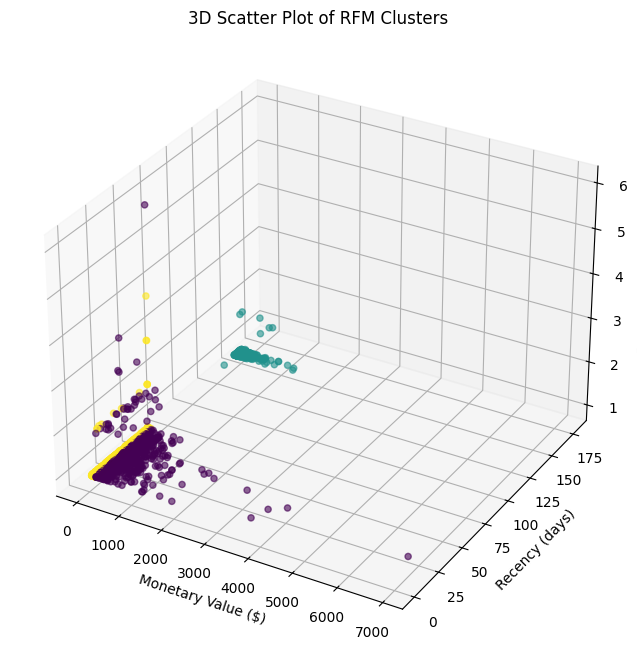

In [66]:
# 3D Scatter Plot of RFM Clusters
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_result['monetary'].astype(float),
    df_result['recency'].astype(float),
    df_result['frequency'].astype(float),
    c=df_result['cluster'], cmap='viridis', alpha=0.6
)

ax.set_xlabel('Monetary Value ($)')
ax.set_ylabel('Recency (days)')
ax.set_zlabel('Frequency (orders)')

ax.set_title('3D Scatter Plot of RFM Clusters')

plt.show()

## 8. Scaler & Model Inspection

Verify scaler parameters and centroid positions.  
These values are saved as artifacts to DB and reused in the daily assign pipeline to transform new data consistently with training.

| Attribute | Description |
|---|---|
| `scaler.feature_names_in_` | Feature order — must match daily input |
| `scaler.center_` | Median per feature `[recency, frequency, monetary]` |
| `scaler.scale_` | IQR per feature `[recency, frequency, monetary]` |
| `km.cluster_centers_` | Centroid coordinates in scaled space |

In [32]:
print(scaler.feature_names_in_)
print(scaler.n_features_in_)
print(scaler.scale_) # -> IQR
print(scaler.center_) # -> median

['recency' 'frequency' 'monetary']
3
[21.          1.          1.14198365]
[24.          1.          4.70066217]
